# Data Loading & Balancing

In [1]:
!pip install "datasets>=2.18.0,<3.0.0" scikit-learn pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
]

CATEGORY_LABELS = {
    "Electronics":               "Electronics",
    "Books":                     "Books",
    "Clothing_Shoes_and_Jewelry": "Clothing",
    "Home_and_Kitchen":           "Home & Kitchen",
    "Sports_and_Outdoors":        "Sports",
}

FILE_STEMS = {
    "Electronics":               "electronics",
    "Books":                     "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Sports_and_Outdoors":        "sports",
}

SAMPLES_PER_CLASS_PER_CATEGORY = 1500
RANDOM_SEED = 104
TEST_SIZE   = 0.2
DRIVE_BASE  = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

drive.mount("/content/drive")
DATA_DIR = f"{DRIVE_BASE}/data"
os.makedirs(DATA_DIR, exist_ok=True)
print("Data directory:", DATA_DIR)

Mounted at /content/drive
Data directory: /content/drive/MyDrive/cross-category-sentiment-robustness/data


In [4]:
def stream_and_sample(category: str, samples_per_class: int, seed: int) -> pd.DataFrame:
    dataset = load_dataset(
        "McAuley-Lab/Amazon-Reviews-2023",
        f"raw_review_{category}",
        split="full",
        streaming=True,
        trust_remote_code=True,
    )

    positives, negatives = [], []
    target = samples_per_class

    for item in dataset:
        if len(positives) >= target and len(negatives) >= target:
            break
        rating = item.get("rating", item.get("overall"))
        if rating is None:
            continue
        rating = float(rating)
        text = str(item.get("text", item.get("reviewText", ""))).strip()
        if not text:
            continue
        if rating >= 4.0 and len(positives) < target:
            positives.append({"text": text, "label": 1, "rating": rating})
        elif rating <= 2.0 and len(negatives) < target:
            negatives.append({"text": text, "label": 0, "rating": rating})

    df = pd.DataFrame(positives + negatives)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f"  {category}: {len(positives)} positive, {len(negatives)} negative")
    return df

In [5]:
all_data: dict[str, pd.DataFrame] = {}

for cat in CATEGORIES:
    print(f"Streaming {cat} …")
    df = stream_and_sample(cat, SAMPLES_PER_CLASS_PER_CATEGORY, RANDOM_SEED)
    all_data[cat] = df

print()
print("All categories loaded.")

Streaming Electronics …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


  Electronics: 1500 positive, 1500 negative
Streaming Books …
  Books: 1500 positive, 1500 negative
Streaming Clothing_Shoes_and_Jewelry …
  Clothing_Shoes_and_Jewelry: 1500 positive, 1500 negative
Streaming Home_and_Kitchen …
  Home_and_Kitchen: 1500 positive, 1500 negative
Streaming Sports_and_Outdoors …
  Sports_and_Outdoors: 1500 positive, 1500 negative

All categories loaded.


In [6]:
splits: dict[str, dict[str, pd.DataFrame]] = {}

for cat, df in all_data.items():
    train_df, test_df = train_test_split(
        df, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df["label"]
    )
    splits[cat] = {"train": train_df.reset_index(drop=True),
                   "test":  test_df.reset_index(drop=True)}

    stem = FILE_STEMS[cat]
    train_df.to_csv(f"{DATA_DIR}/{stem}_train.csv", index=False)
    test_df.to_csv(f"{DATA_DIR}/{stem}_test.csv",  index=False)
    print(f"{cat}: train={len(train_df)}, test={len(test_df)}")

Electronics: train=2400, test=600
Books: train=2400, test=600
Clothing_Shoes_and_Jewelry: train=2400, test=600
Home_and_Kitchen: train=2400, test=600
Sports_and_Outdoors: train=2400, test=600


## Visualisation 1: Class distribution per category

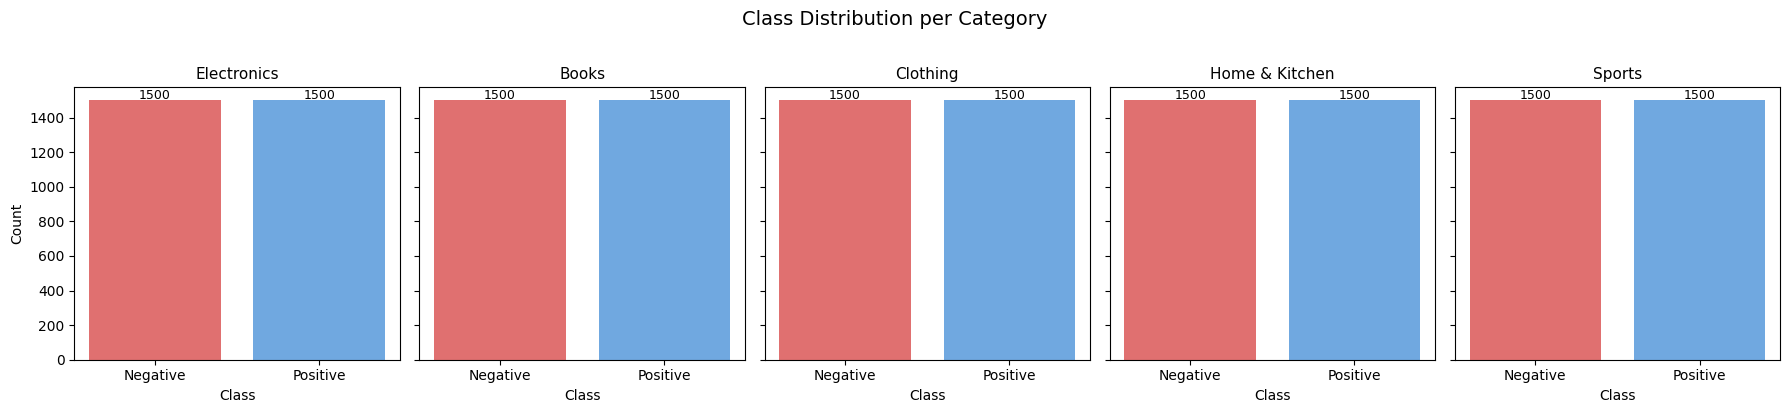

In [7]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(18, 4), sharey=True)

for ax, cat in zip(axes, CATEGORIES):
    counts = all_data[cat]["label"].value_counts().sort_index()
    ax.bar(["Negative", "Positive"], counts.values, color=["#e07070", "#70a8e0"])
    ax.set_title(CATEGORY_LABELS[cat], fontsize=11)
    ax.set_xlabel("Class")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha="center", fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Class Distribution per Category", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Visualisation 2: Review length distribution

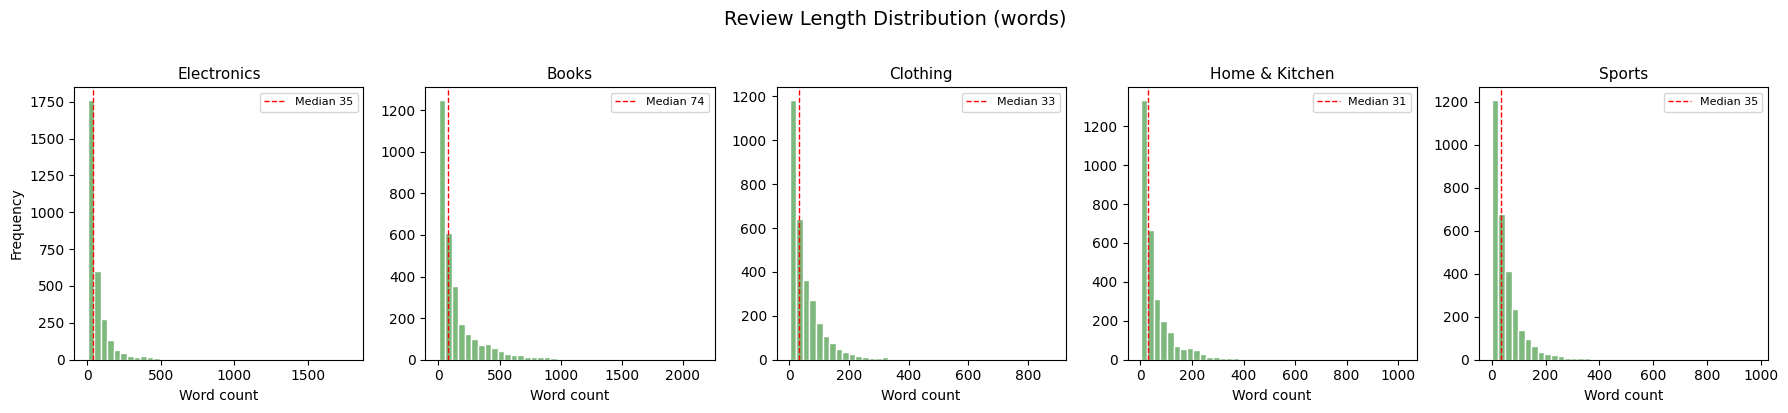

In [8]:
fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(18, 4), sharey=False)

for ax, cat in zip(axes, CATEGORIES):
    lengths = all_data[cat]["text"].str.split().str.len()
    ax.hist(lengths, bins=40, color="#7db87d", edgecolor="white")
    ax.set_title(CATEGORY_LABELS[cat], fontsize=11)
    ax.set_xlabel("Word count")
    ax.axvline(lengths.median(), color="red", linestyle="--", linewidth=1,
               label=f"Median {lengths.median():.0f}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Frequency")
fig.suptitle("Review Length Distribution (words)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Visualisation 3: Sample reviews (5 positive + 5 negative per category)

In [9]:
for cat in CATEGORIES:
    df = all_data[cat]
    pos = df[df["label"] == 1].sample(5, random_state=RANDOM_SEED)
    neg = df[df["label"] == 0].sample(5, random_state=RANDOM_SEED)
    sample = pd.concat([pos, neg])[["label", "text"]].copy()
    sample["text"] = sample["text"].str[:120] + "…"
    sample["sentiment"] = sample["label"].map({1: "positive", 0: "negative"})
    sample = sample[["sentiment", "text"]].reset_index(drop=True)

    print()
    print(f"Category: {CATEGORY_LABELS[cat]}")
    print(sample.to_string(index=False))


Category: Electronics
sentiment                                                                                                                      text
 positive                                                                                                          Worth the money…
 positive Stickers such as these have been very popular with my eighteen year old daughter. She uses them to cover her notebooks, …
 positive Bought this for a new laptop and I am thrilled about lightweight this case is.  Really nice for travel because it is so …
 positive This power strip is perfect for your desk. It has a long cord so you can easily put it within reach of a wall outlet. It…
 positive                                                                                               This is nice. Great sound.…
 negative                                                                                                       Absolutely garbage…
 negative This pretty much is a reasonably nice lapto

## Summary statistics

In [10]:
rows = []
for cat in CATEGORIES:
    df   = all_data[cat]
    stem = FILE_STEMS[cat]
    rows.append({
        "Category":  CATEGORY_LABELS[cat],
        "Total":     len(df),
        "Positive":  (df["label"] == 1).sum(),
        "Negative":  (df["label"] == 0).sum(),
        "Train":     len(splits[cat]["train"]),
        "Test":      len(splits[cat]["test"]),
        "Median words": int(df["text"].str.split().str.len().median()),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

      Category  Total  Positive  Negative  Train  Test  Median words
   Electronics   3000      1500      1500   2400   600            35
         Books   3000      1500      1500   2400   600            74
      Clothing   3000      1500      1500   2400   600            33
Home & Kitchen   3000      1500      1500   2400   600            31
        Sports   3000      1500      1500   2400   600            35
